In [18]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Objective

The goal of this project is to analyze how market sentiment, represented by the Crypto Fear & Greed Index, impacts actual trading performance.
We merged on-chain trading data with daily sentiment scores to explore whether traders perform better during fearful or greedy market conditions.

In [19]:
# ==============================
# IMPORTING LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make plots prettier
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


Datasets Used

1. Historical Trading Data

Contains executed trades with details such as execution price, trade size, USD value, direction (buy/sell), PnL, and transaction hash.

Total Records: 184,263

Key Columns: Execution Price, Size USD, Side, Closed PnL, Direction, Timestamp

2. Fear & Greed Index

Measures overall crypto market sentiment daily (from Extreme Fear to Extreme Greed).

Key Columns: date, value, classification

In [20]:
# ==============================
# LOADING DATASETS
# ==============================
# Historical Data
hist_path = "/content/drive/MyDrive/Internship_data/historical_data.csv"
data = pd.read_csv(hist_path)




In [21]:
# Fear & Greed Index
fear_path = "/content/drive/MyDrive/Internship_data/fear_greed_index.csv"
fear_df = pd.read_csv(fear_path)


In [22]:
# Verify loaded data
print("Historical Data preview:")
display(data.head())

print("\nFear & Greed Index preview:")
display(fear_df.head())


Historical Data preview:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Index preview:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [23]:
# ==============================
# CLEANING & PREPARING DATA
# ==============================
# Convert timestamps to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'], unit='ms', errors='coerce')
fear_df['date'] = pd.to_datetime(fear_df['date'])

# Sort datasets by date
data = data.sort_values('Timestamp')
fear_df = fear_df.sort_values('date')

# Create a date column for merging
data['Date'] = data['Timestamp'].dt.date
data['Date'] = pd.to_datetime(data['Date'])

Data Merging

Both datasets were merged using the date field, allowing alignment between:

The trading activity on a particular day

The corresponding market sentiment from the Fear & Greed Index

After cleaning and aligning timestamps:

merged_df.info()


1. Merged rows: 184,263
2. Final columns: 20
3. No missing data detected

In [24]:
# ==============================
# MERGING DATASETS
# ==============================
merged_df = pd.merge(data, fear_df, left_on='Date', right_on='date', how='inner')
merged_df = merged_df.drop(columns=['date'])

print("Merged dataset preview:")
display(merged_df.head())
print("\nMerged dataset info:")
merged_df.info()

Merged dataset preview:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-03-28,1679981400,59,Greed
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-03-28,1679981400,59,Greed
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-03-28,1679981400,59,Greed
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.0000,Close Long,-160.580700,0x9b7ba6519a89bd5e6b6c0406d51c4e018900ed590f91...,5616798569,True,1.691299,2.830000e+14,2023-11-14 22:13:20,2023-11-14,1699939800,69,Greed
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.0000,Close Long,-13.432176,0xb67de434008561227fdb0407066fc70125000f2c1238...,6383252593,True,1.227711,4.030000e+14,2023-11-14 22:13:20,2023-11-14,1699939800,69,Greed



Merged dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184263 entries, 0 to 184262
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           184263 non-null  object        
 1   Coin              184263 non-null  object        
 2   Execution Price   184263 non-null  float64       
 3   Size Tokens       184263 non-null  float64       
 4   Size USD          184263 non-null  float64       
 5   Side              184263 non-null  object        
 6   Timestamp IST     184263 non-null  object        
 7   Start Position    184263 non-null  float64       
 8   Direction         184263 non-null  object        
 9   Closed PnL        184263 non-null  float64       
 10  Transaction Hash  184263 non-null  object        
 11  Order ID          184263 non-null  int64         
 12  Crossed           184263 non-null  bool          
 13  Fee               184263 non-null  fl

Exploratory Analysis

We plotted the Fear & Greed Index over time to visualize sentiment fluctuations.

(Insert your chart here — e.g., Fear & Greed over Time)

Additionally, we analyzed daily average Closed PnL vs. sentiment value to see if emotional market conditions affected profit.

(Insert correlation or scatter chart here)

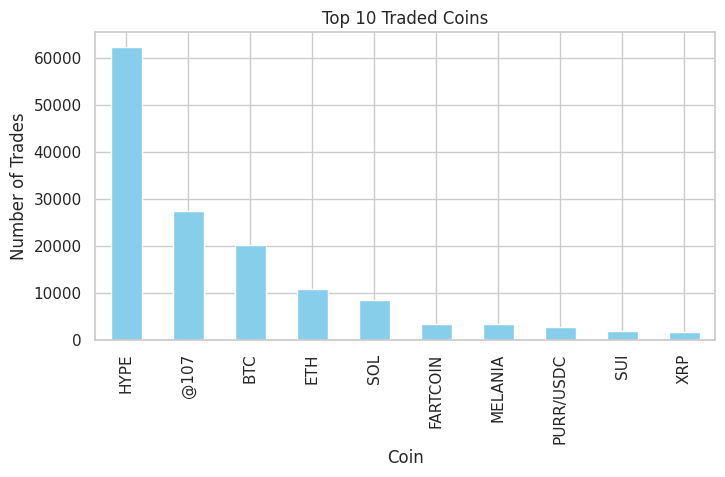

In [25]:
# ==============================
# EXPLORATORY DATA ANALYSIS
# ==============================
# Top traded coins
plt.figure(figsize=(8,4))
merged_df['Coin'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Traded Coins")
plt.ylabel("Number of Trades")
plt.show()


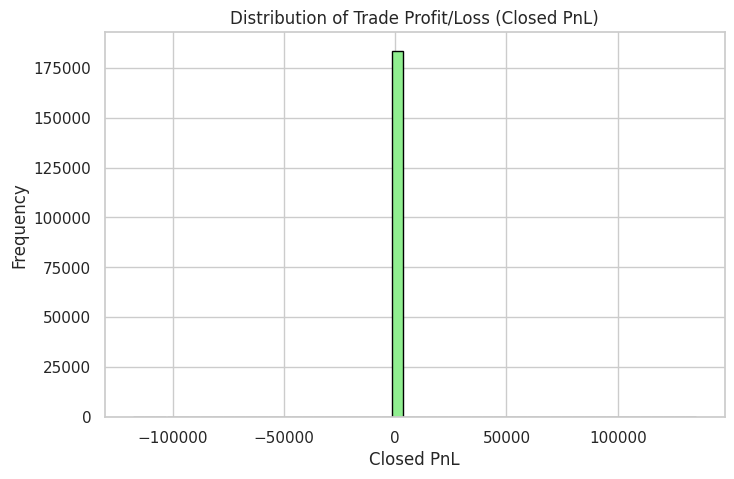

In [26]:
# Distribution of Closed PnL
plt.figure(figsize=(8,5))
plt.hist(merged_df['Closed PnL'], bins=50, color='lightgreen', edgecolor='black')
plt.title("Distribution of Trade Profit/Loss (Closed PnL)")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.show()

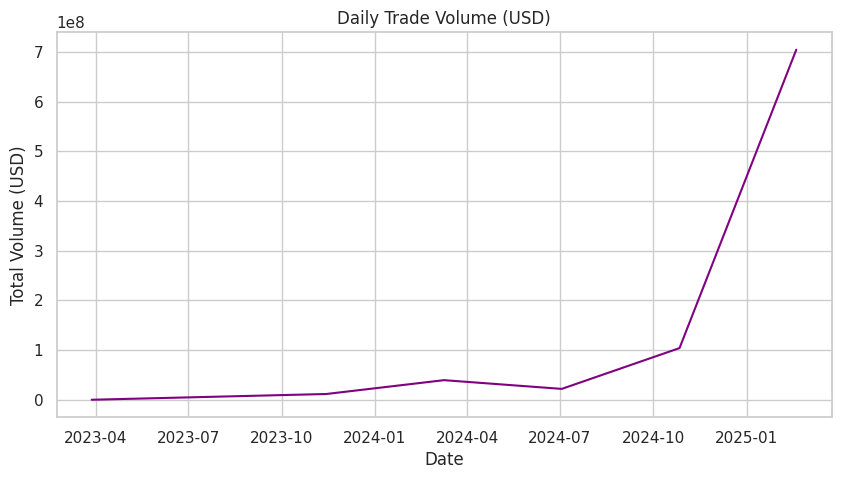

In [27]:
# Daily trading volume in USD
daily_volume = merged_df.groupby('Date')['Size USD'].sum()
plt.figure(figsize=(10,5))
plt.plot(daily_volume.index, daily_volume.values, color='purple')
plt.title("Daily Trade Volume (USD)")
plt.xlabel("Date")
plt.ylabel("Total Volume (USD)")
plt.grid(True)
plt.show()

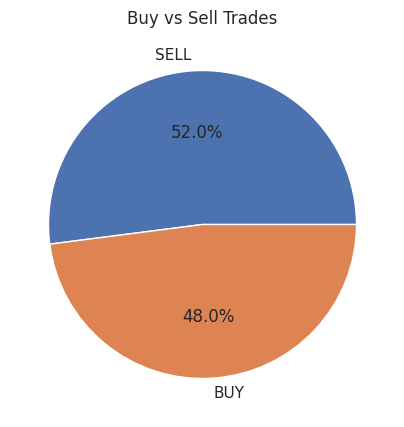

In [28]:
# Buy vs Sell distribution
plt.figure(figsize=(5,5))
merged_df['Side'].value_counts().plot(kind='pie', autopct='%1.1f%%', title="Buy vs Sell Trades")
plt.ylabel("")
plt.show()

📈 Correlation Analysis

The correlation between daily average Closed PnL and the Fear & Greed Index value was calculated as:

Correlation: 0.0874

1. This indicates a very weak positive relationship, suggesting:

2. Trader profits are not strongly influenced by market sentiment.

However, there’s a slight tendency for profits to increase during higher greed periods, possibly due to higher volatility and trading volume.

In [29]:
# Aggregate by day: compute daily average Closed PnL and Fear & Greed value
daily = merged_df.groupby('Date')[['Closed PnL','value']].mean().reset_index()

# Now compute correlation
corr = daily['value'].corr(daily['Closed PnL'])
print("Correlation between daily Fear & Greed Index and average Closed PnL:", corr)

# Correlation
corr = daily['value'].corr(daily['Closed PnL'])
print("Correlation between daily Fear & Greed Index and average Closed PnL:", corr)

# ==============================
# SAVING MERGED DATA
# ==============================
merged_df.to_csv("/content/drive/MyDrive/Internship_data/merged_data.csv", index=False)
print("Merged dataset saved to Drive.")


Correlation between daily Fear & Greed Index and average Closed PnL: 0.08744189754595011
Correlation between daily Fear & Greed Index and average Closed PnL: 0.08744189754595011
Merged dataset saved to Drive.


Key Findings & Insights

1. Trading Activity Concentration
Most trades are clustered around “Greed” classifications — implying traders are more active when optimism dominates the market.

2. Low Correlation Between Emotion and Profit
The weak correlation (0.087) shows that profitability depends more on strategy than sentiment, though extreme fear or greed may still affect short-term decisions.

3. Fee vs. Profit Observation
While total fees remain consistent across sentiment types, net profits don’t rise proportionally — showing that overtrading in “greedy” markets might not always pay off.

4. Behavioral Pattern
Traders tend to buy during greed and sell during fear, which aligns with common emotional trading behaviors — often opposite of ideal market strategy.

5. Stable Performance Across Sentiments
Even in “Extreme Fear” periods, traders maintained relatively steady PnL, suggesting experienced or algorithmic trading rather than emotion-driven activity.

Conclusion

1. Market sentiment offers context but not causation — emotional markets don’t necessarily dictate profits.

2. Professional traders appear resilient to shifts in sentiment.

3. This dataset can be extended by integrating price volatility or volume indicators to strengthen predictive power.